In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [ ]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('India-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    22.87
1950-02-01    20.58
1950-03-01    15.56
1950-04-01    19.73
1950-05-01    18.35
              ...  
2023-08-01     7.95
2023-09-01     8.78
2023-10-01    21.58
2023-11-01    23.71
2023-12-01    25.36
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

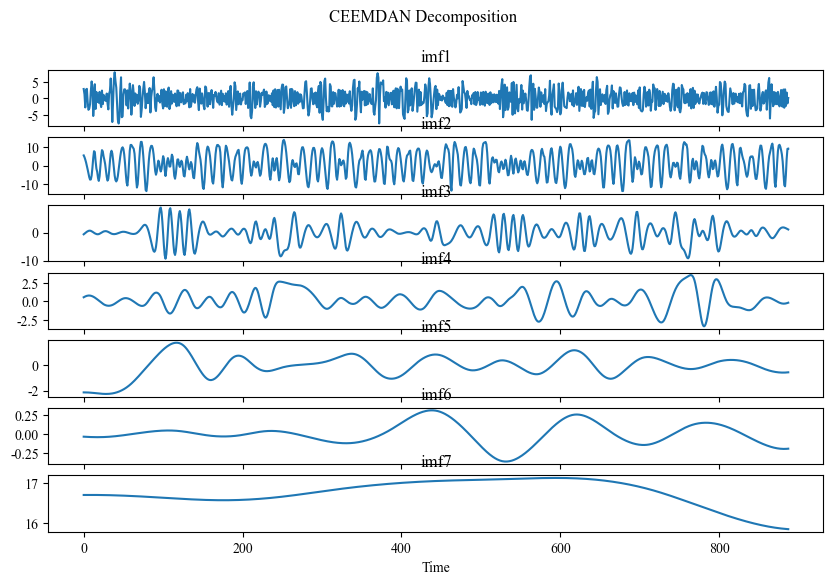

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [11]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-INDIA-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1       imf2      imf3      imf4      imf5      imf6       imf7
0    2.856675   5.545371 -0.606822  0.540064 -2.136921 -0.037129  16.708762
1    1.227131   4.584988 -0.367298  0.601232 -2.137176 -0.037793  16.708916
2   -2.751868   3.251340 -0.126820  0.654600 -2.137877 -0.038426  16.709051
3    2.705719   1.690636  0.103174  0.699406 -2.139077 -0.039026  16.709167
4    2.899453  -0.124436  0.311251  0.734890 -2.140830 -0.039592  16.709264
..        ...        ...       ...       ...       ...       ...        ...
883  2.749757 -11.260670  1.703286 -0.310586 -0.588828 -0.197958  15.855000
884 -2.308822  -5.262532  1.572873 -0.291701 -0.585468 -0.197557  15.853206
885  1.769420   3.578972  1.423770 -0.265681 -0.581051 -0.196939  15.851508
886 -1.532723   9.127164  1.270691 -0.233327 -0.575606 -0.196106  15.849906
887  0.124374   9.221448  1.125441 -0.195443 -0.569158 -0.195061  15.848400

[888 rows x 7 columns]
